In [1]:
# Dataforberedelse

import pandas as pd
import numpy as np

# Last inn datasettet
df = pd.read_csv('CustomerChurn.csv')

print("Første 5 rader i datasettet:")
print(df.head(5))

print("\n")

print("Info om datasettet:")
print(df.info())

print("\n")

print("Tomme verdier:")
print(df.isnull().sum())

print("\n")

print("Indeks:")
print(df.columns)



Første 5 rader i datasettet:
   Call  Failure  Complains  Subscription  Length  Charge  Amount  \
0              8          0                    38               0   
1              0          0                    39               0   
2             10          0                    37               0   
3             10          0                    38               0   
4              3          0                    38               0   

   Seconds of Use  Frequency of use  Frequency of SMS  \
0            4370                71                 5   
1             318                 5                 7   
2            2453                60               359   
3            4198                66                 1   
4            2393                58                 2   

   Distinct Called Numbers  Age Group  Tariff Plan  Status  Age  \
0                       17          3            1       1   30   
1                        4          2            1       2   25   
2           

In [2]:
# Statistisk tabell

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

summary_stats = df[numeric_cols].agg(['mean', 'median', 'std', 'min', 'max']).transpose()
print("Statistisk tabell:")
print(summary_stats)

print("\n")

churn_distribution = df['Churn'].value_counts(normalize=True) * 100
print("Churn i %:")
print(churn_distribution)


Statistisk tabell:
                                mean   median          std   min       max
Call  Failure               7.627937     6.00     7.263886   0.0     36.00
Complains                   0.076508     0.00     0.265851   0.0      1.00
Subscription  Length       32.541905    35.00     8.573482   3.0     47.00
Charge  Amount              0.942857     0.00     1.521072   0.0     10.00
Seconds of Use           4472.459683  2990.00  4197.908687   0.0  17090.00
Frequency of use           69.460635    54.00    57.413308   0.0    255.00
Frequency of SMS           73.174921    21.00   112.237560   0.0    522.00
Distinct Called Numbers    23.509841    21.00    17.217337   0.0     97.00
Age Group                   2.826032     3.00     0.892555   1.0      5.00
Tariff Plan                 1.077778     1.00     0.267864   1.0      2.00
Status                      1.248254     1.00     0.432069   1.0      2.00
Age                        30.998413    30.00     8.831095  15.0     55.00
Custom

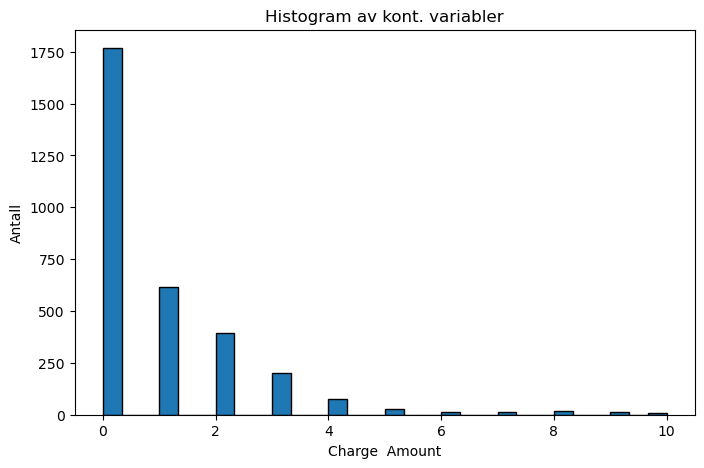

In [3]:
# Visualisering

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.hist(df['Charge  Amount'], bins=30, edgecolor = 'black')
plt.xlabel('Charge  Amount')
plt.ylabel('Antall')
plt.title('Histogram av kont. variabler')
plt.show()


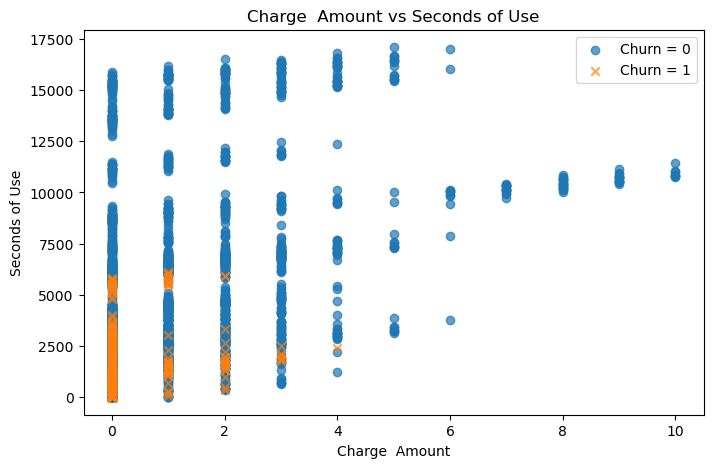

In [4]:
# Scatterplot

markers = {0: 'o', 1: 'x'}

plt.figure(figsize=(8, 5))
for churn_val in df['Churn'].unique():
    subset = df[df['Churn'] == churn_val]
    plt.scatter(subset['Charge  Amount'], subset['Seconds of Use'], marker=markers[churn_val], label=f'Churn = {churn_val}', alpha=0.7)
plt.xlabel('Charge  Amount')
plt.ylabel('Seconds of Use')
plt.title('Charge  Amount vs Seconds of Use')
plt.legend()
plt.show()


In [5]:
# Modelltilpasning

import statsmodels.api as sm

results_list = []
for var in numeric_cols:
    if var == 'Churn':  # Skip the outcome variable
        continue
    X = sm.add_constant(df[var])
    y = df['Churn']
    model = sm.Logit(y, X).fit(disp=0)
    results_list.append({
        'Variable': var,
        'Coefficient': model.params[var],
        'p-value': model.pvalues[var],
        'AIC': model.aic
    })
    
results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('p-value')
print("Results from single-variable models (top 8 significant):")
print(results_df.head(8))


Results from single-variable models (top 8 significant):
                   Variable  Coefficient        p-value          AIC
10                   Status     2.779735  8.496984e-126  2064.479501
1                 Complains     3.766407   4.980643e-95  2133.118306
5          Frequency of use    -0.029796   1.816168e-56  2307.306128
4            Seconds of Use    -0.000517   1.259891e-52  2265.108348
7   Distinct Called Numbers    -0.069440   7.237424e-52  2422.681891
12           Customer Value    -0.005519   6.564365e-38  2251.339497
3            Charge  Amount    -0.930579   2.158306e-28  2518.384174
6          Frequency of SMS    -0.018332   9.765625e-23  2461.511617


In [6]:
# Stegvis Forover-analyse

def stepwise_forward_selection(data, outcome, candidate_vars):
    selected_vars = []
    current_aic = None
    models_info = []
    
    while True:
        aic_with_candidates = []
        for var in candidate_vars:
            if var in selected_vars:
                continue
            X = sm.add_constant(data[selected_vars + [var]])
            y = data[outcome]
            model = sm.Logit(y, X).fit(disp=0)
            aic_with_candidates.append((model.aic, var, model))
        if not aic_with_candidates:
            break
        best_aic, best_var, best_model = min(aic_with_candidates, key=lambda x: x[0])
        # Beregn deviance som -2*llf
        deviance = -2 * best_model.llf
        
        if current_aic is None or best_aic < current_aic:
            selected_vars.append(best_var)
            candidate_vars.remove(best_var)
            current_aic = best_aic
            models_info.append({
                'Modell': '+'.join(selected_vars),
                'Deviance': deviance,
                'Antall parametre': len(best_model.params),
                'AIC': best_aic
            })
        else:
            break
    return selected_vars, models_info

# Bruk funksjonen:
candidate_vars = [col for col in numeric_cols if col != 'Churn']
selected_vars, models_info = stepwise_forward_selection(df, 'Churn', candidate_vars.copy())

stepwise_df = pd.DataFrame(models_info)
print("Valgte variabler ved stegvis forover-analyse:")
print(selected_vars)

print("\n")

print("Modellinformasjon per steg:")
print(stepwise_df)


Valgte variabler ved stegvis forover-analyse:
['Status', 'Complains', 'Customer Value', 'Frequency of use', 'Call  Failure', 'Frequency of SMS', 'Charge  Amount', 'Subscription  Length', 'Age Group']


Modellinformasjon per steg:
                                              Modell     Deviance  \
0                                             Status  2060.479501   
1                                   Status+Complains  1645.178583   
2                    Status+Complains+Customer Value  1521.695675   
3   Status+Complains+Customer Value+Frequency of use  1485.483897   
4  Status+Complains+Customer Value+Frequency of u...  1459.521371   
5  Status+Complains+Customer Value+Frequency of u...  1415.863662   
6  Status+Complains+Customer Value+Frequency of u...  1399.618644   
7  Status+Complains+Customer Value+Frequency of u...  1389.870918   
8  Status+Complains+Customer Value+Frequency of u...  1387.092716   

   Antall parametre          AIC  
0                 2  2064.479501  
1        

Sammendrag for den endelige modellen:
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 3150
Model:                          Logit   Df Residuals:                     3140
Method:                           MLE   Df Model:                            9
Date:                Fri, 11 Apr 2025   Pseudo R-squ.:                  0.4937
Time:                        10:51:41   Log-Likelihood:                -693.55
converged:                       True   LL-Null:                       -1369.9
Covariance Type:            nonrobust   LLR p-value:                1.225e-285
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.5957      0.461     -5.629      0.000      -3.499      -1.692
Status                   1.4587      0.197      7.392      0.00

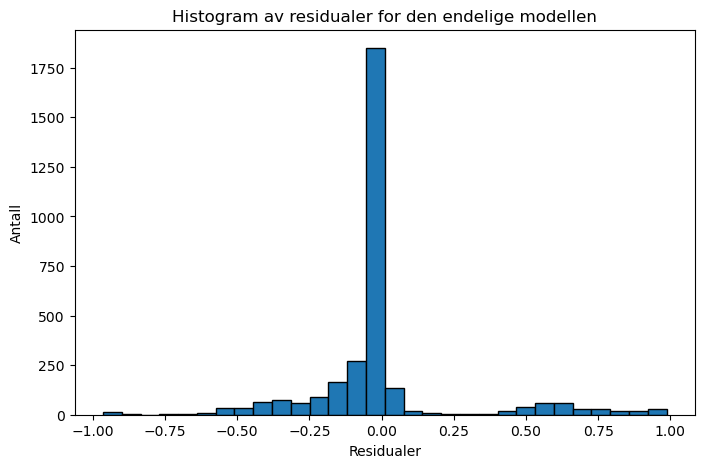

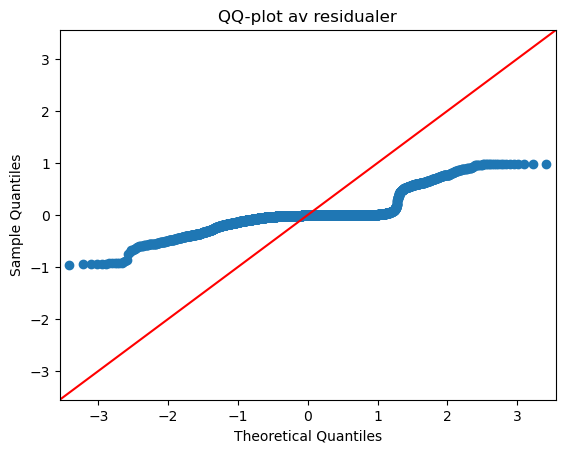

In [7]:
# Endelig Modell og Evaluering

X_final = sm.add_constant(df[selected_vars])
y = df['Churn']
final_model = sm.Logit(y, X_final).fit(disp=0)
print("Sammendrag for den endelige modellen:")
print(final_model.summary())

# Beregn deviance for den endelige modellen
model_deviance = -2 * final_model.llf

# Tilpass en nullmodell med kun konstant
null_X = sm.add_constant(np.ones(len(y)))
null_model = sm.Logit(y, null_X).fit(disp=0)
null_deviance = -2 * null_model.llf

# Beregn pseudo-R2
pseudo_R2 = 1 - model_deviance / null_deviance
print("\nPseudo R2 for den endelige modellen:", pseudo_R2)

# Visualiser residualene
residuals = final_model.resid_response
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.xlabel("Residualer")
plt.ylabel("Antall")
plt.title("Histogram av residualer for den endelige modellen")
plt.show()

sm.qqplot(residuals, line='45')
plt.title("QQ-plot av residualer")
plt.show()


In [8]:
# Evaluering av Prediksjonsytelse

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

X = df[selected_vars]
y = df['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

log_reg = LogisticRegression(max_iter=5000)
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1])
print("Logistisk regresjon – Test accuracy:", accuracy)
print("Logistisk regresjon – AUC:", auc)


Logistisk regresjon – Test accuracy: 0.8804232804232804
Logistisk regresjon – AUC: 0.9231075477350488


In [9]:
# Evaluering av Tilfeldige Modeller

import random

X_all = df[candidate_vars]
y_all = df['Churn']
X_all_train, X_all_test, y_all_train, y_all_test = train_test_split(X_all, y_all, test_size=0.3, random_state=42)

models_results = []
random_models = []
for i in range(16):
    subset = random.sample(candidate_vars, random.randint(1, len(candidate_vars)))
    random_models.append(subset)

for i, features in enumerate(random_models):
    X_train_temp = X_all_train[features]
    X_test_temp = X_all_test[features]
    model_temp = LogisticRegression(max_iter=5000)
    model_temp.fit(X_train_temp, y_all_train)
    y_pred_temp = model_temp.predict(X_test_temp)
    accuracy_temp = accuracy_score(y_all_test, y_pred_temp)
    auc_temp = roc_auc_score(y_all_test, model_temp.predict_proba(X_test_temp)[:, 1])
    models_results.append({
        'Model': f"Model {i+1}",
        'Variabler': ', '.join(features),
        'Accuracy': accuracy_temp,
        'AUC': auc_temp
    })

models_results_df = pd.DataFrame(models_results)
print("\nSammenligning av 16 modeller:")
print(models_results_df)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite


Sammenligning av 16 modeller:
       Model                                          Variabler  Accuracy  \
0    Model 1  Distinct Called Numbers, Customer Value, Statu...  0.883598   
1    Model 2  Tariff Plan, Distinct Called Numbers, Call  Fa...  0.829630   
2    Model 3                                   Frequency of use  0.828571   
3    Model 4  Age, Age Group, Status, Distinct Called Number...  0.881481   
4    Model 5  Customer Value, Tariff Plan, Call  Failure, Ag...  0.829630   
5    Model 6  Age, Charge  Amount, Distinct Called Numbers, ...  0.822222   
6    Model 7                                   Frequency of use  0.828571   
7    Model 8             Frequency of use, Subscription  Length  0.828571   
8    Model 9  Customer Value, Charge  Amount, Complains, Sta...  0.885714   
9   Model 10  Frequency of SMS, Subscription  Length, Second...  0.884656   
10  Model 11           Customer Value, Age Group, Call  Failure  0.838095   
11  Model 12  Complains, Distinct Called Numb

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
# Ekstra Oppgave

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print("Random Forest – Test accuracy:", accuracy_rf)
print("Random Forest – AUC:", auc_rf)


Random Forest – Test accuracy: 0.9354497354497354
Random Forest – AUC: 0.9752100972833199
